In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
diabetes_df = pd.read_csv('diabetes_data.csv')
diabetes_df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [3]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


- Total Entries: It has 100,000 rows of data, numbered from 0 to 99,999.
- Total Columns: There are 9 columns in this table.
- Column Details: Each column is listed with its name, how many non-empty values it has, and its data type.

# **1. Univariate Analysis (Single Variables)**

## **1.1. Categorical Variables**

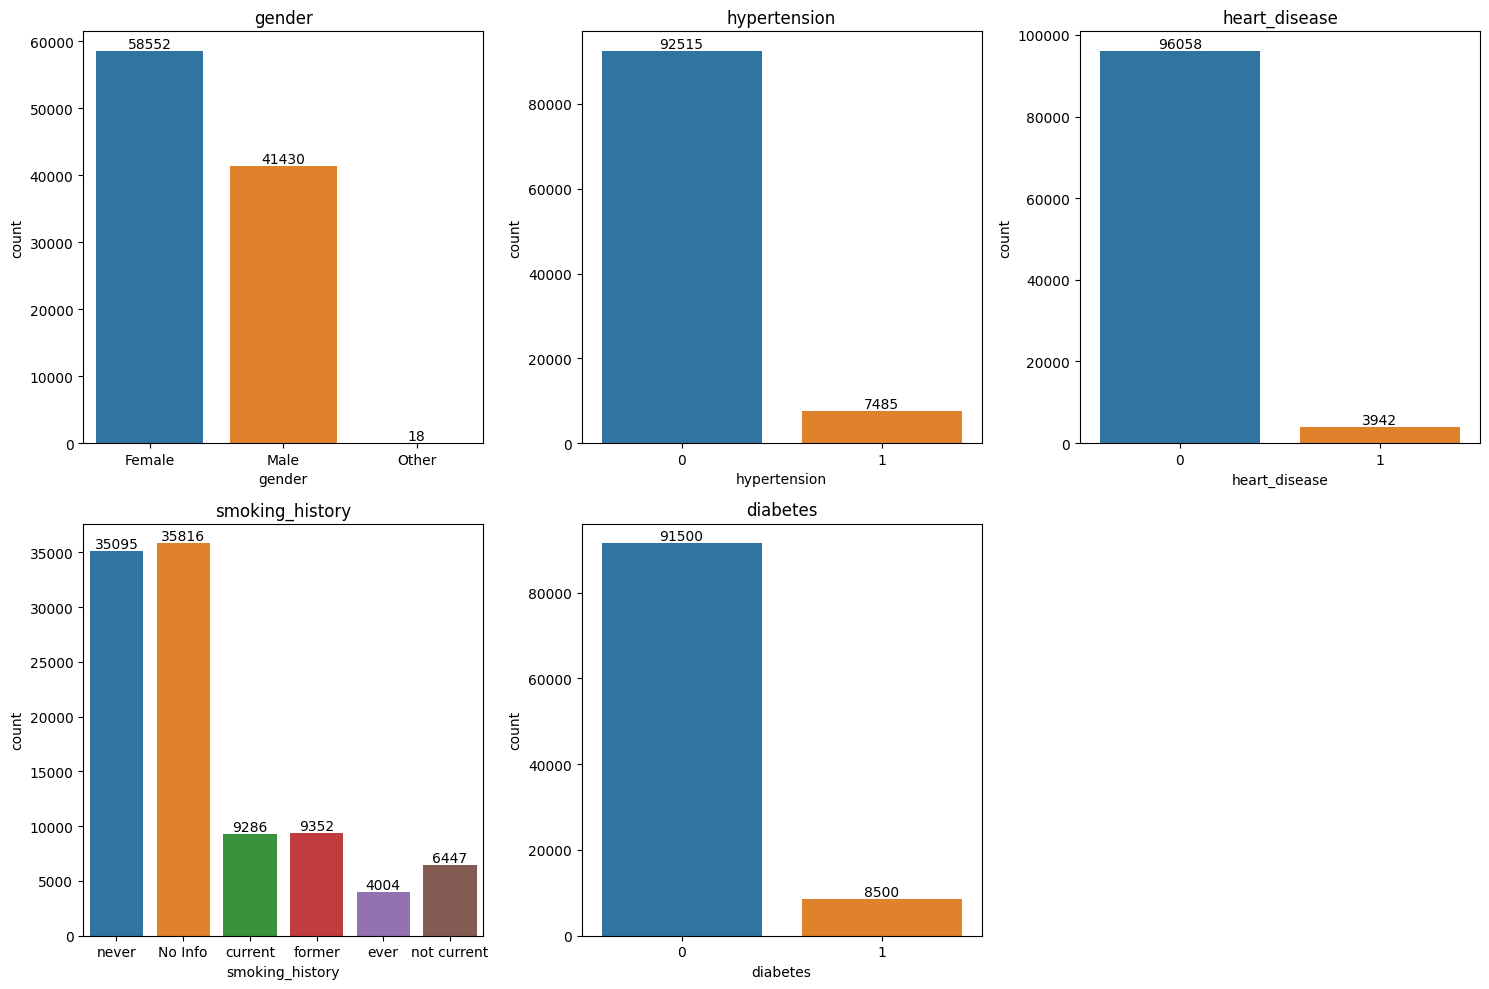

In [4]:
columns_to_plot = [
    "gender",
    "hypertension",
    "heart_disease",
    "smoking_history",
    "diabetes"
]

# Determine the number of rows and columns for the subplot grid
n_cols = 3
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    sns.countplot(x=col, data=diabetes_df, hue=col, legend=False, ax=ax)
    ax.set_title(f'{col}')

    # Add counts on top of each bar
    for p in ax.patches:
        ax.annotate(
            str(int(p.get_height())),
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 5),
            textcoords='offset points'
        )

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**These charts show the count of people in different categories.**
- **Gender:** There are more Females (about 58,552) than Males (41,430). The "Other" category has a very small number (18).
- **Hypertension (High Blood Pressure):** Most people in this group do not have hypertension (92,515). A smaller number of people do have it (7,485).
*Heart Disease:* The vast majority of people do not have heart disease (96,058). Only a small number have it (3,942).
- **Smoking History:** The two biggest groups are people who "never" smoked (35,095) and those with "No Info" (35,816). Smaller groups include "former" smokers, "current" smokers, and others.
- **Diabetes:** Similar to the heart and blood pressure charts, most people do not have diabetes (91,500). A smaller group does have diabetes (8,500).

**Summary**
- Overall, this data shows a group where most people are healthy (no diabetes, heart disease, or high blood pressure). There are more women than men, and many people have never smoked or have no smoking information listed.

## **1.2. Numerical Variables**

1. **Age distribution (histogram/boxplot)**

2. **BMI distribution and descriptive statistics (mean, median, std, min, max)**

3. **HbA1c_level distribution and clinical range analysis (normal 4-5.7, prediabetic 5.7-6.4, diabetic >6.5)**

4. **Blood glucose level distribution (fasting glucose ranges)**

5. **Outlier detection for each numeric feature using IQR method**

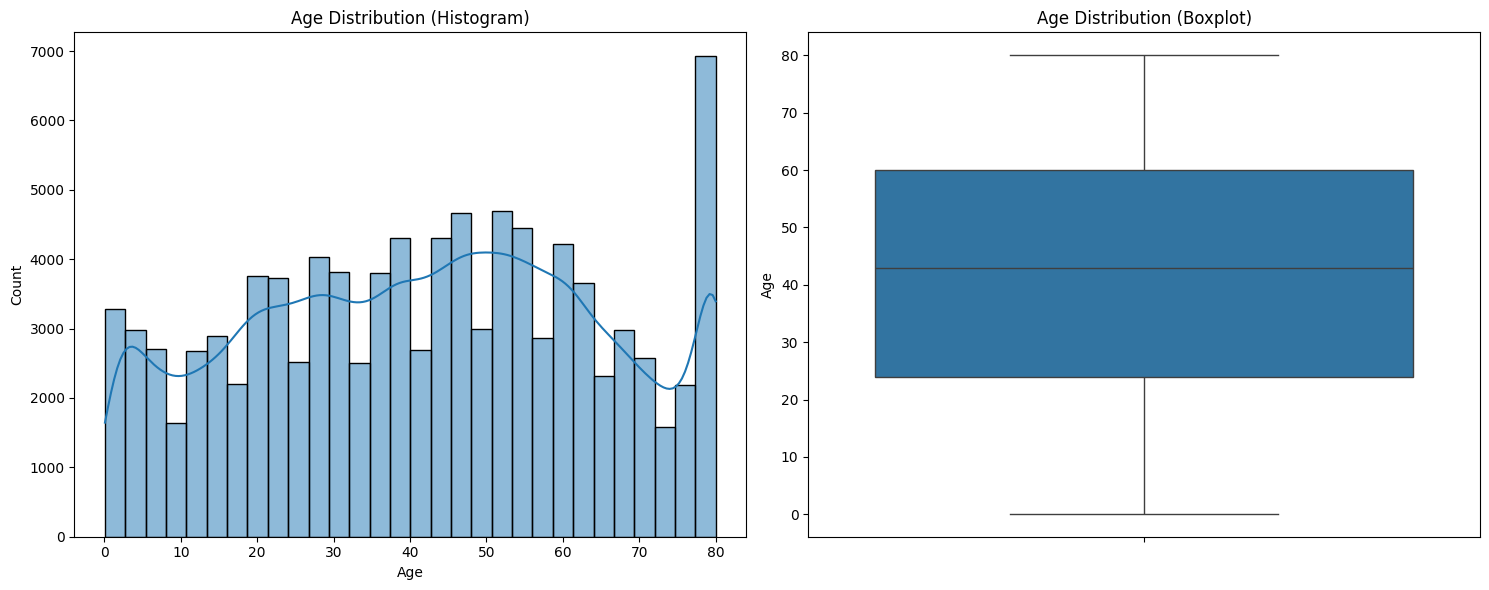

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Histogram for Age Distribution
sns.histplot(diabetes_df['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution (Histogram)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Boxplot for Age Distribution
sns.boxplot(y=diabetes_df['age'], ax=axes[1])
axes[1].set_title('Age Distribution (Boxplot)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

- The ages are spread out widely. There are many people around 50 to 60 years old.
- There is also a very tall bar at the far right (age 80), meaning there is a large group of older individuals in this dataset.

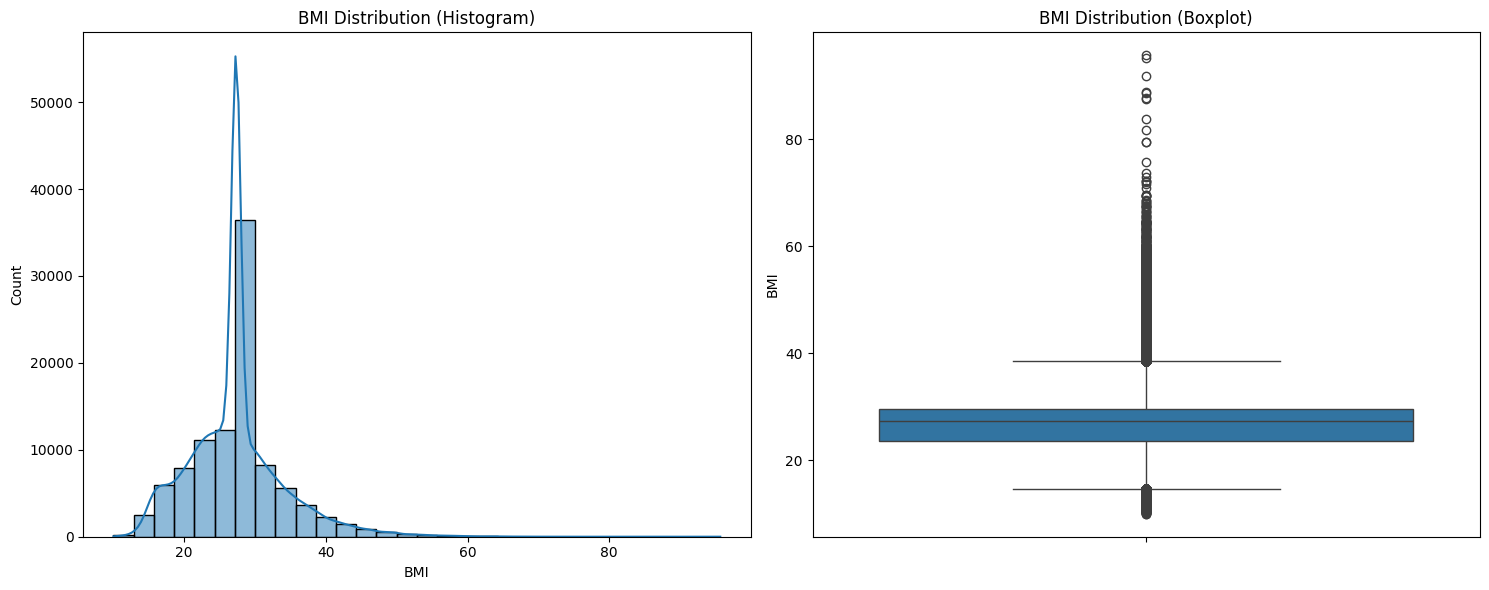

Descriptive Statistics for BMI:
count    100000.000000
mean         27.320767
std           6.636783
min          10.010000
25%          23.630000
50%          27.320000
75%          29.580000
max          95.690000
Name: bmi, dtype: float64


In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Histogram for BMI Distribution
sns.histplot(diabetes_df['bmi'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('BMI Distribution (Histogram)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')

# Boxplot for BMI Distribution
sns.boxplot(y=diabetes_df['bmi'], ax=axes[1])
axes[1].set_title('BMI Distribution (Boxplot)')
axes[1].set_ylabel('BMI')

plt.tight_layout()
plt.show()

# Descriptive statistics for BMI
print("Descriptive Statistics for BMI:")
print(diabetes_df['bmi'].describe())

- The graph has one very tall, sharp peak.
- It shows that a large number of people have a BMI around 27.
- The line drops off quickly, meaning fewer people have very high or very low BMI.

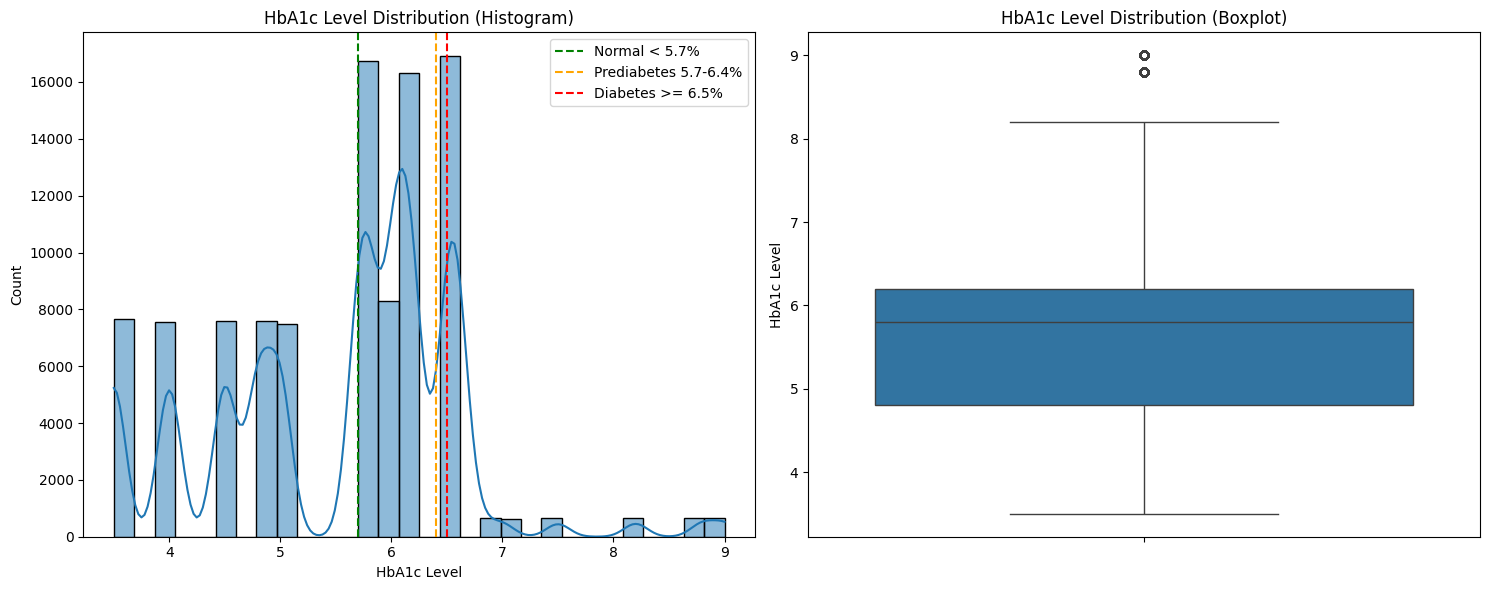

Descriptive Statistics for HbA1c_level:
count    100000.000000
mean          5.527507
std           1.070672
min           3.500000
25%           4.800000
50%           5.800000
75%           6.200000
max           9.000000
Name: HbA1c_level, dtype: float64


In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Histogram for HbA1c_level Distribution
sns.histplot(diabetes_df['HbA1c_level'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('HbA1c Level Distribution (Histogram)')
axes[0].set_xlabel('HbA1c Level')
axes[0].set_ylabel('Count')

# Add vertical lines for clinical ranges
axes[0].axvline(x=5.7, color='green', linestyle='--', label='Normal < 5.7%')
axes[0].axvline(x=6.4, color='orange', linestyle='--', label='Prediabetes 5.7-6.4%')
axes[0].axvline(x=6.5, color='red', linestyle='--', label='Diabetes >= 6.5%')
axes[0].legend()

# Boxplot for HbA1c_level Distribution
sns.boxplot(y=diabetes_df['HbA1c_level'], ax=axes[1])
axes[1].set_title('HbA1c Level Distribution (Boxplot)')
axes[1].set_ylabel('HbA1c Level')

plt.tight_layout()
plt.show()

# Descriptive statistics for HbA1c_level
print("Descriptive Statistics for HbA1c_level:")
print(diabetes_df['HbA1c_level'].describe())

The bars are grouped into specific spikes. The colored dashed lines help separate the groups:
- Green Line: Marks the "Normal" level (below 5.7%).
- Orange Line: Marks the "Prediabetes" range (5.7% to 6.4%).
- Red Line: Marks the "Diabetes" level (6.5% and higher). A large number of people in this graph fall into the "Prediabetes" and "Diabetes" ranges.

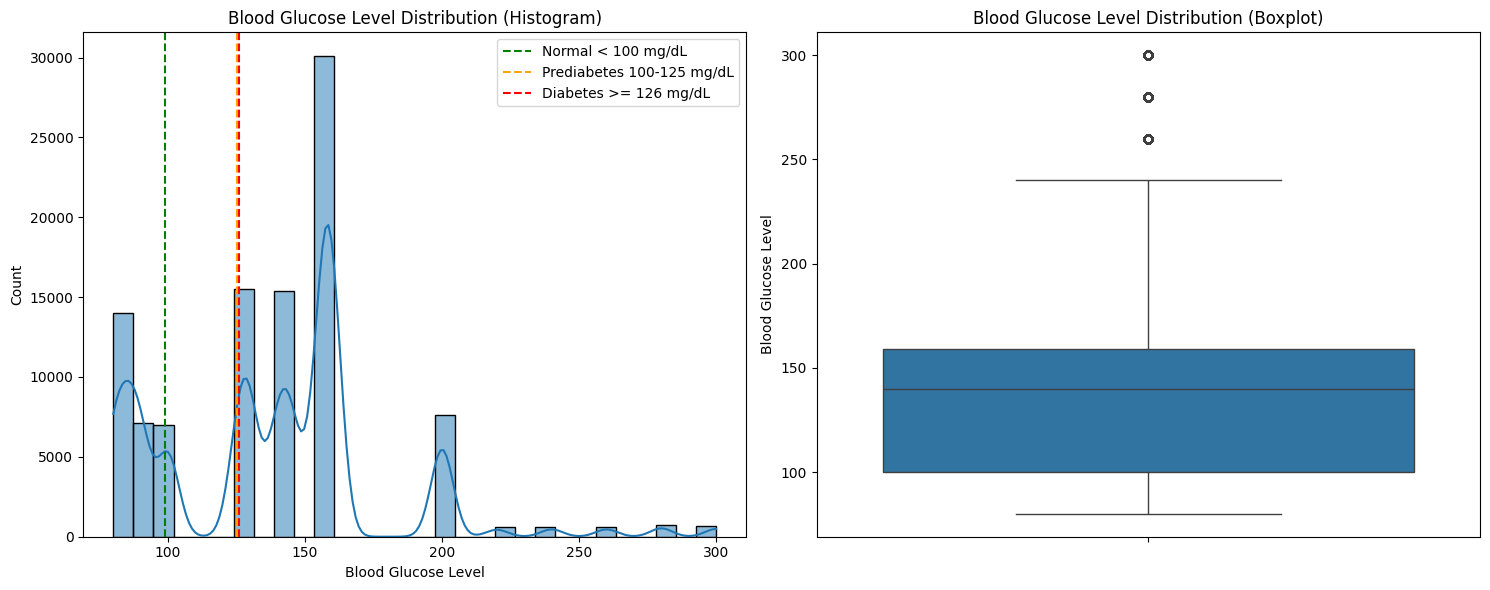

Descriptive Statistics for blood_glucose_level:
count    100000.000000
mean        138.058060
std          40.708136
min          80.000000
25%         100.000000
50%         140.000000
75%         159.000000
max         300.000000
Name: blood_glucose_level, dtype: float64


In [8]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Histogram for blood_glucose_level Distribution
sns.histplot(diabetes_df['blood_glucose_level'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Blood Glucose Level Distribution (Histogram)')
axes[0].set_xlabel('Blood Glucose Level')
axes[0].set_ylabel('Count')

# Add vertical lines for common fasting glucose ranges
axes[0].axvline(x=99, color='green', linestyle='--', label='Normal < 100 mg/dL')
axes[0].axvline(x=125, color='orange', linestyle='--', label='Prediabetes 100-125 mg/dL')
axes[0].axvline(x=126, color='red', linestyle='--', label='Diabetes >= 126 mg/dL')
axes[0].legend()

# Boxplot for blood_glucose_level Distribution
sns.boxplot(y=diabetes_df['blood_glucose_level'], ax=axes[1])
axes[1].set_title('Blood Glucose Level Distribution (Boxplot)')
axes[1].set_ylabel('Blood Glucose Level')

plt.tight_layout()
plt.show()

# Descriptive statistics for blood_glucose_level
print("Descriptive Statistics for blood_glucose_level:")
print(diabetes_df['blood_glucose_level'].describe())

This graph also has distinct spikes rather than a smooth hill.
- Green Line (Normal): Below 100.
- Red Line (Diabetes): Above 126. There is a very tall bar around 160, meaning a significant number of people have high blood glucose levels well into the diabetes range.

In [9]:
numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

print("Outlier Detection using IQR Method:")
for col in numeric_cols:
    Q1 = diabetes_df[col].quantile(0.25)
    Q3 = diabetes_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = diabetes_df[(diabetes_df[col] < lower_bound) | (diabetes_df[col] > upper_bound)]
    num_outliers = len(outliers)
    percentage_outliers = (num_outliers / len(diabetes_df)) * 100

    print(f"\nColumn: {col}")
    print(f"  Q1 (25th percentile): {Q1:.2f}")
    print(f"  Q3 (75th percentile): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {num_outliers}")
    print(f"  Percentage of outliers: {percentage_outliers:.2f}%")

Outlier Detection using IQR Method:

Column: age
  Q1 (25th percentile): 24.00
  Q3 (75th percentile): 60.00
  IQR: 36.00
  Lower Bound: -30.00
  Upper Bound: 114.00
  Number of outliers: 0
  Percentage of outliers: 0.00%

Column: bmi
  Q1 (25th percentile): 23.63
  Q3 (75th percentile): 29.58
  IQR: 5.95
  Lower Bound: 14.71
  Upper Bound: 38.50
  Number of outliers: 7086
  Percentage of outliers: 7.09%

Column: HbA1c_level
  Q1 (25th percentile): 4.80
  Q3 (75th percentile): 6.20
  IQR: 1.40
  Lower Bound: 2.70
  Upper Bound: 8.30
  Number of outliers: 1315
  Percentage of outliers: 1.31%

Column: blood_glucose_level
  Q1 (25th percentile): 100.00
  Q3 (75th percentile): 159.00
  IQR: 59.00
  Lower Bound: 11.50
  Upper Bound: 247.50
  Number of outliers: 2038
  Percentage of outliers: 2.04%


- Age: There are zero outliers in this category. All age values fit inside the expected range (between -30 and 114). This means the age data is very consistent.

- BMI (Body Mass Index): This category has the highest number of outliers. About 7.09% of the people (2,043 individuals) are outside the standard range of 14.71 to 38.50. This suggests that a noticeable group of people have a BMI that is much higher or lower than the majority.

- HbA1c Level: There are very few outliers here. Only 1.31% of the people (376 individuals) fall outside the expected range of 2.70 to 8.30.

- Blood Glucose Level: This also has a small number of outliers. About 2.04% of the people (573 individuals) have blood sugar levels outside the range of 11.50 to 247.50.

**Summary:**  
- The Age data is completely within the normal range.

- The BMI data varies the most, with many people falling outside the average range.

- The blood health numbers (HbA1c and Glucose) are mostly consistent, with only a small number of unusual values.

# **2. Bivariate Analysis (Feature vs. Target: Diabetes)**

## **2.1. Categorical vs. Diabetes**

1. **Diabetes rate by gender (Male vs Female)**

2. **Diabetes rate by smoking history categories**

3. **Diabetes rate for hypertensive vs. non-hypertensive patients**

4. **Diabetes rate for patients with/without heart disease**

5. **Cross-tabulation with chi-square tests for categorical associations**

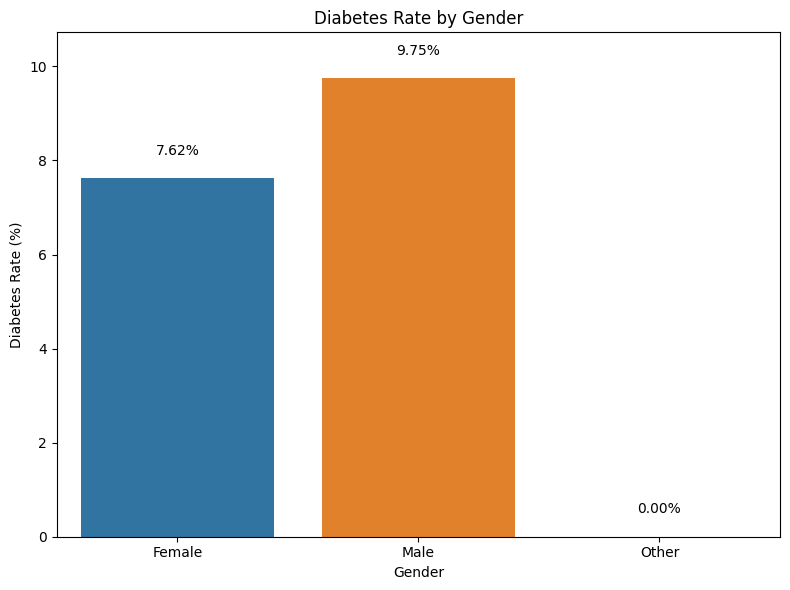

In [10]:
diabetes_by_gender = diabetes_df.groupby('gender')['diabetes'].mean().reset_index()
diabetes_by_gender['diabetes_percentage'] = diabetes_by_gender['diabetes'] * 100

plt.figure(figsize=(8, 6))
sns.barplot(x='gender', y='diabetes_percentage', data=diabetes_by_gender, hue='gender', legend=False)
plt.title('Diabetes Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Diabetes Rate (%)')
plt.ylim(0, diabetes_by_gender['diabetes_percentage'].max() * 1.1) # Set y-axis limit slightly above max percentage

# Add percentage labels on top of the bars
for index, row in diabetes_by_gender.iterrows():
    plt.text(index, row['diabetes_percentage'] + 0.5, f"{row['diabetes_percentage']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

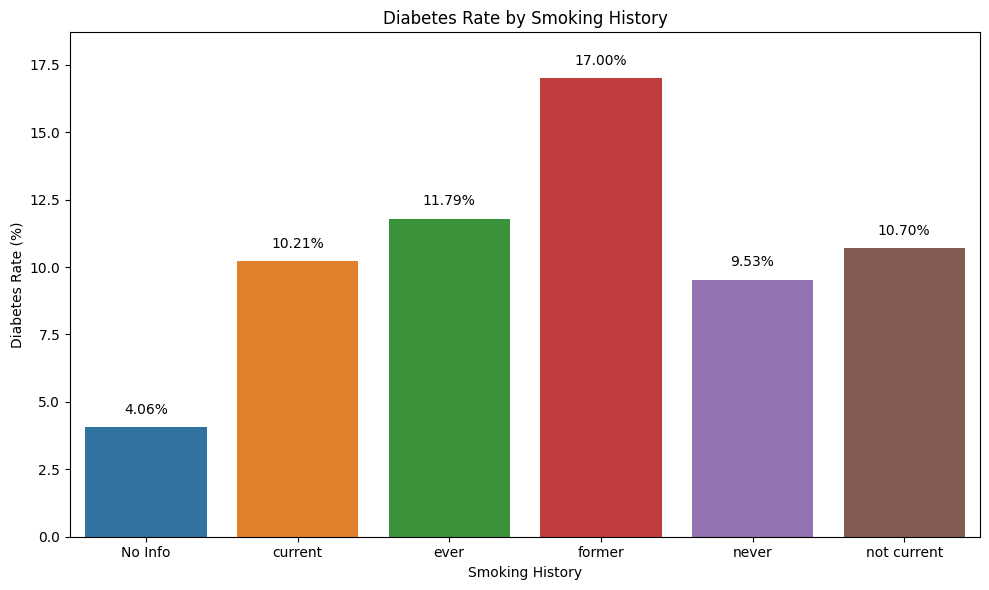

In [11]:
diabetes_by_smoking = diabetes_df.groupby('smoking_history')['diabetes'].mean().reset_index()
diabetes_by_smoking['diabetes_percentage'] = diabetes_by_smoking['diabetes'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='smoking_history', y='diabetes_percentage', data=diabetes_by_smoking, hue='smoking_history', legend=False)
plt.title('Diabetes Rate by Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Diabetes Rate (%)')
plt.ylim(0, diabetes_by_smoking['diabetes_percentage'].max() * 1.1)
for index, row in diabetes_by_smoking.iterrows():
    plt.text(index, row['diabetes_percentage'] + 0.5, f"{row['diabetes_percentage']:.2f}%", color='black', ha="center")
plt.tight_layout()
plt.show()

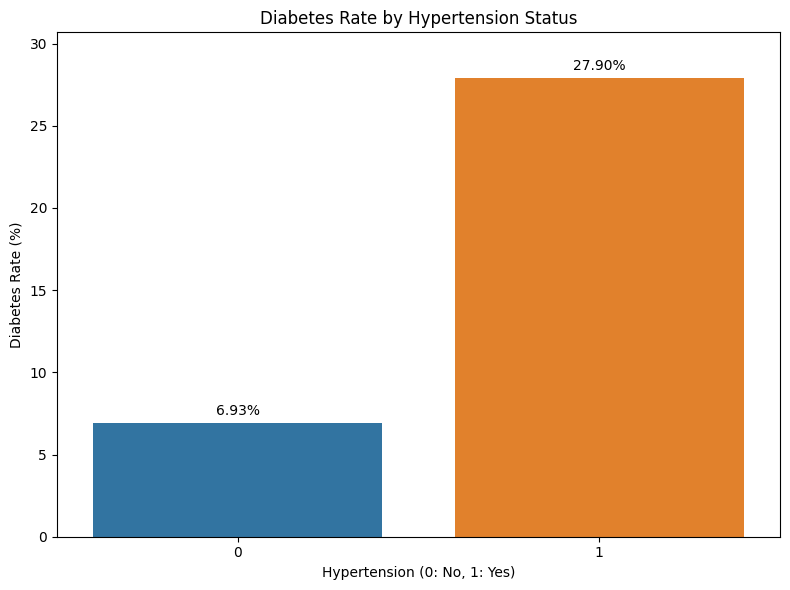

In [12]:
diabetes_by_hypertension = diabetes_df.groupby('hypertension')['diabetes'].mean().reset_index()
diabetes_by_hypertension['diabetes_percentage'] = diabetes_by_hypertension['diabetes'] * 100

plt.figure(figsize=(8, 6))
sns.barplot(x='hypertension', y='diabetes_percentage', data=diabetes_by_hypertension, hue='hypertension', legend=False)
plt.title('Diabetes Rate by Hypertension Status')
plt.xlabel('Hypertension (0: No, 1: Yes)')
plt.ylabel('Diabetes Rate (%)')
plt.ylim(0, diabetes_by_hypertension['diabetes_percentage'].max() * 1.1)
for index, row in diabetes_by_hypertension.iterrows():
    plt.text(index, row['diabetes_percentage'] + 0.5, f"{row['diabetes_percentage']:.2f}%", color='black', ha="center")
plt.tight_layout()
plt.show()

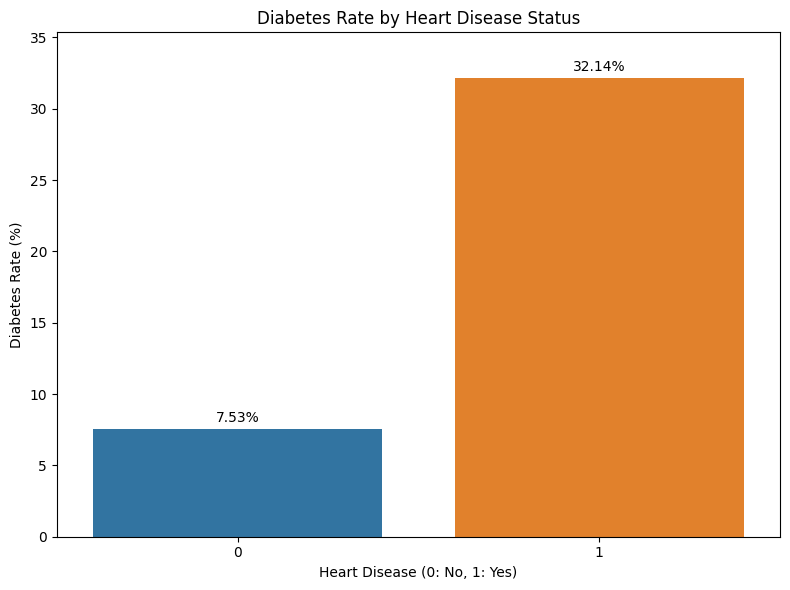

In [13]:
diabetes_by_heart_disease = diabetes_df.groupby('heart_disease')['diabetes'].mean().reset_index()
diabetes_by_heart_disease['diabetes_percentage'] = diabetes_by_heart_disease['diabetes'] * 100

plt.figure(figsize=(8, 6))
sns.barplot(x='heart_disease', y='diabetes_percentage', data=diabetes_by_heart_disease, hue='heart_disease', legend=False)
plt.title('Diabetes Rate by Heart Disease Status')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Diabetes Rate (%)')
plt.ylim(0, diabetes_by_heart_disease['diabetes_percentage'].max() * 1.1)
for index, row in diabetes_by_heart_disease.iterrows():
    plt.text(index, row['diabetes_percentage'] + 0.5, f"{row['diabetes_percentage']:.2f}%", color='black', ha="center")
plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import chi2_contingency

categorical_cols = ['gender', 'smoking_history', 'hypertension', 'heart_disease']

print("\nChi-Square Test Results for Categorical Associations with Diabetes:")
for col in categorical_cols:
    contingency_table = pd.crosstab(diabetes_df[col], diabetes_df['diabetes'])
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    print(f"\n{col} vs. Diabetes:")
    print(f"  Chi-square statistic: {chi2:.2f}")
    print(f"  P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  (Statistically significant association)")
    else:
        print("  (No statistically significant association)")


Chi-Square Test Results for Categorical Associations with Diabetes:

gender vs. Diabetes:
  Chi-square statistic: 143.22
  P-value: 0.000
  (Statistically significant association)

smoking_history vs. Diabetes:
  Chi-square statistic: 1956.09
  P-value: 0.000
  (Statistically significant association)

hypertension vs. Diabetes:
  Chi-square statistic: 3910.71
  P-value: 0.000
  (Statistically significant association)

heart_disease vs. Diabetes:
  Chi-square statistic: 2945.85
  P-value: 0.000
  (Statistically significant association)


## **2.2. Numerical vs. Diabetes**

1. **Age comparison: mean/median age of diabetic vs. non-diabetic patients**

2. **BMI comparison: average BMI by diabetes status (obesity link analysis)
HbA1c levels by diabetes status (clinical validation - should be highly correlated)**

3. **Blood glucose levels by diabetes status**

4. **Boxplots plots for all numeric features split by diabetes status**

In [15]:
age_by_diabetes = diabetes_df.groupby('diabetes')['age'].agg(['mean', 'median'])
print("Mean and Median Age by Diabetes Status:")
print(age_by_diabetes)

bmi_by_diabetes = diabetes_df.groupby('diabetes')['bmi'].agg(['mean', 'median'])
print("\nMean and Median BMI by Diabetes Status:")
print(bmi_by_diabetes)

hba1c_by_diabetes = diabetes_df.groupby('diabetes')['HbA1c_level'].agg(['mean', 'median'])
print("\nMean and Median HbA1c Level by Diabetes Status:")
print(hba1c_by_diabetes)

blood_glucose_by_diabetes = diabetes_df.groupby('diabetes')['blood_glucose_level'].agg(['mean', 'median'])
print("\nMean and Median Blood Glucose Level by Diabetes Status:")
print(blood_glucose_by_diabetes)

Mean and Median Age by Diabetes Status:
               mean  median
diabetes                   
0         40.115187    40.0
1         60.946588    62.0

Mean and Median BMI by Diabetes Status:
               mean  median
diabetes                   
0         26.887163   27.32
1         31.988382   29.97

Mean and Median HbA1c Level by Diabetes Status:
              mean  median
diabetes                  
0         5.396761     5.8
1         6.934953     6.6

Mean and Median Blood Glucose Level by Diabetes Status:
                mean  median
diabetes                    
0         132.852470   140.0
1         194.094706   160.0


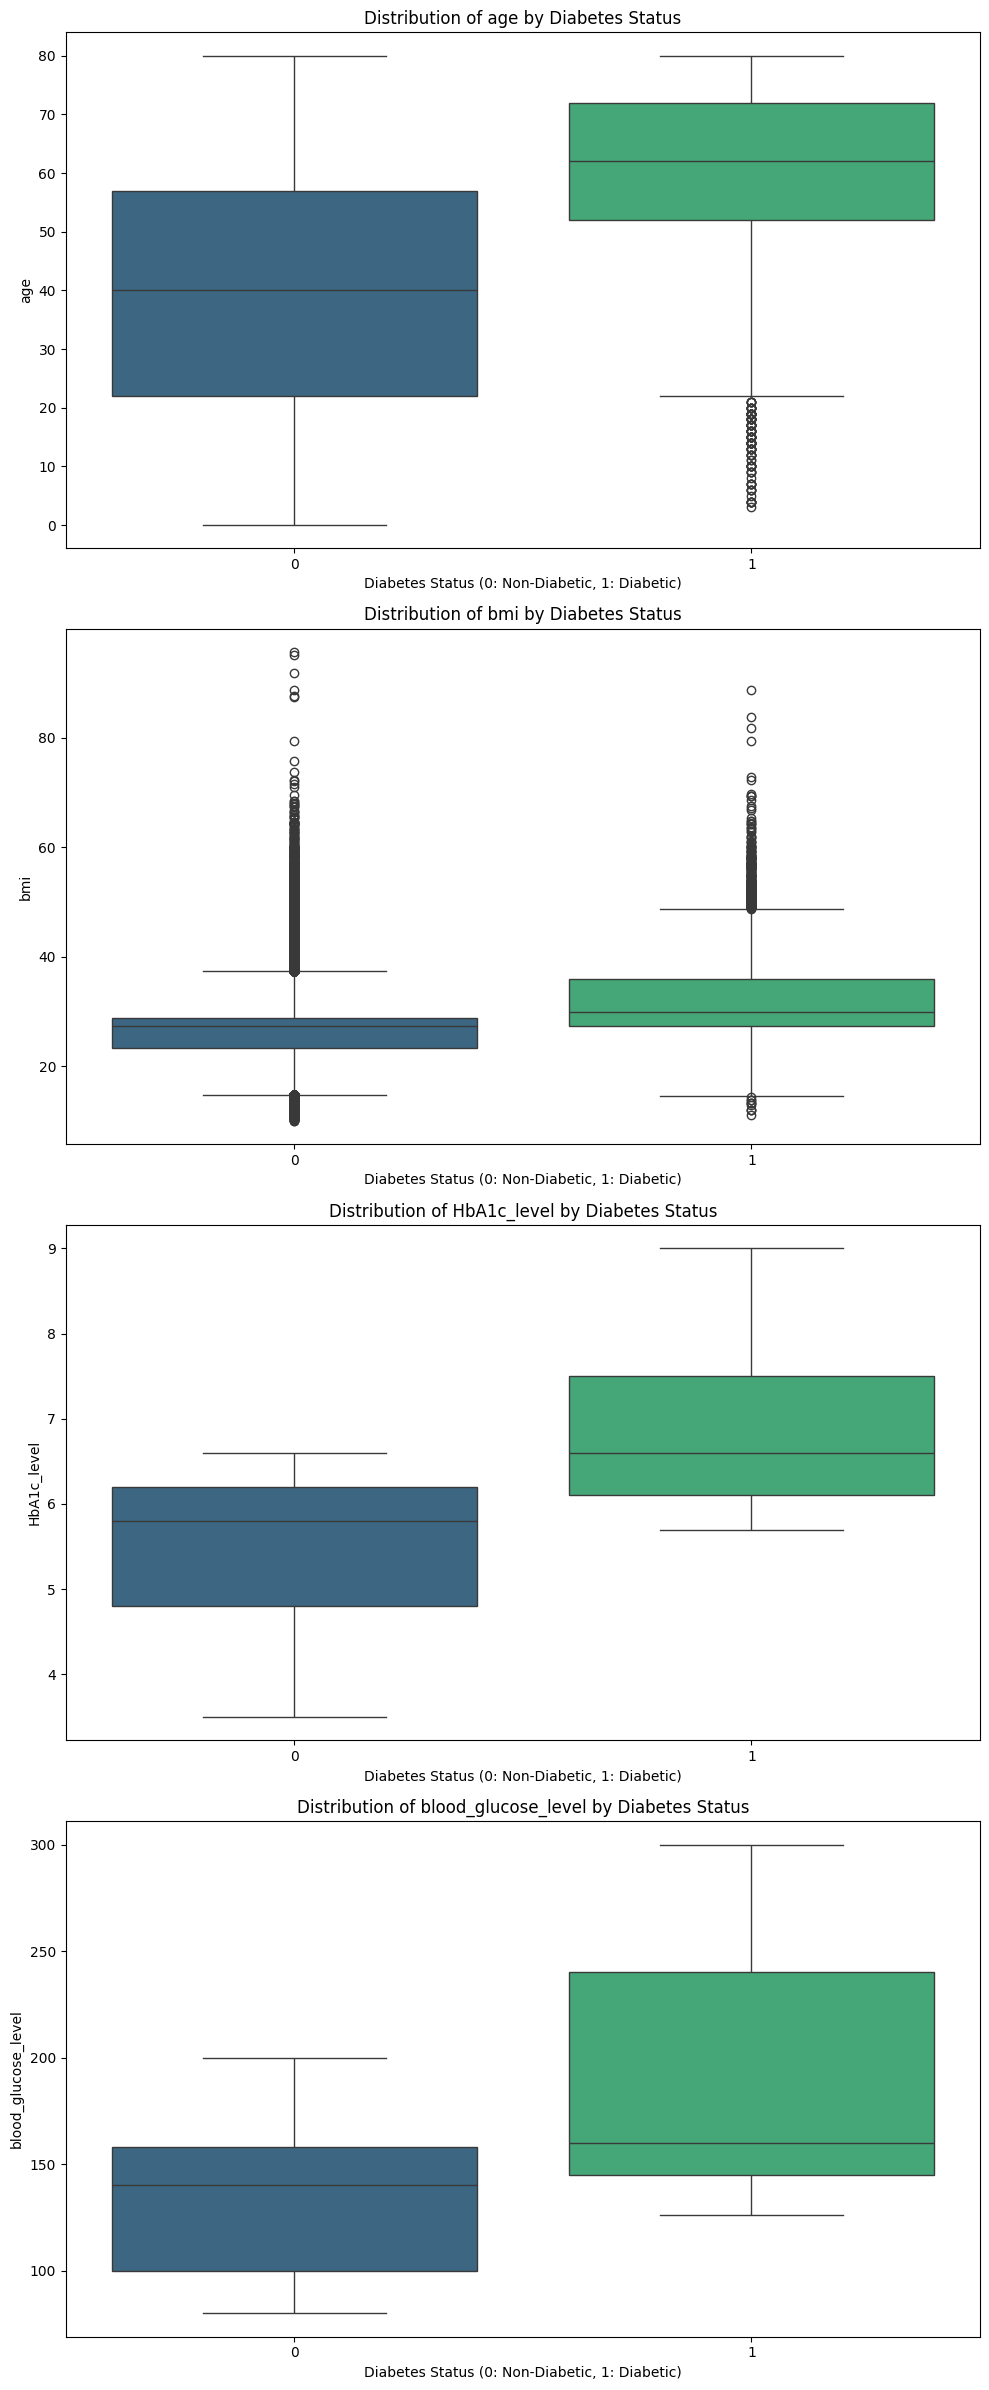

In [16]:
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(nrows=len(numerical_features), ncols=1, figsize=(10, 6 * len(numerical_features)))

for i, feature in enumerate(numerical_features):
    sns.boxplot(x='diabetes', y=feature, data=diabetes_df, ax=axes[i], hue='diabetes', palette='viridis', legend=False)
    axes[i].set_title(f'Distribution of {feature} by Diabetes Status')
    axes[i].set_xlabel('Diabetes Status (0: Non-Diabetic, 1: Diabetic)')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

### **Summary:**

*   **Age:** Diabetic patients have a significantly higher mean age of approximately 60.95 years (median 62.0 years) compared to non-diabetic patients, who have a mean age of approximately 40.12 years (median 40.0 years). This indicates a strong correlation between older age and diabetes status.

*   **BMI:** Diabetic patients show a considerably higher mean BMI of approximately 31.99 (median 29.97), placing them in the obese or borderline obese category. Non-diabetic patients have a mean BMI of around 26.89 (median 27.32), generally falling into the overweight category.

*   **HbA1c Levels:** Diabetic patients exhibit markedly elevated HbA1c levels, with a mean of approximately 6.93% (median 6.6%), which is above the 6.5% diagnostic threshold for diabetes. Non-diabetic patients have a mean HbA1c of about 5.40% (median 5.8%), falling within the normal to prediabetic range.

*   **Blood Glucose Levels:** There is a significant difference in blood glucose levels, with diabetic patients having a mean of approximately 194.09 mg/dL (median 160.0 mg/dL), well above the 126 mg/dL diagnostic threshold. Interestingly, non-diabetic patients also show a mean blood glucose level of approximately 132.85 mg/dL (median 140.0 mg/dL), suggesting that a portion of this group might be prediabetic or diabetic based on this specific metric.

*   **Visual Distributions:** Boxplots visually confirm these differences, showing clear upward shifts in the distributions of age, BMI, HbA1c levels, and blood glucose levels for diabetic patients compared to non-diabetic patients.


# **3. Multivariate Analysis**

## **3.1. Correlation & Relationships**

1. **Correlation matrix/heatmap for all numerical features (age, BMI, HbA1c, blood glucose)**

2. **Pairplot analysis for numeric features colored by diabetes status**

3. **Age groups analysis: Create age brackets (0-18, 19-35, 36-50, 51-65, 65+) and analyze diabetes rates across them**

In [17]:
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

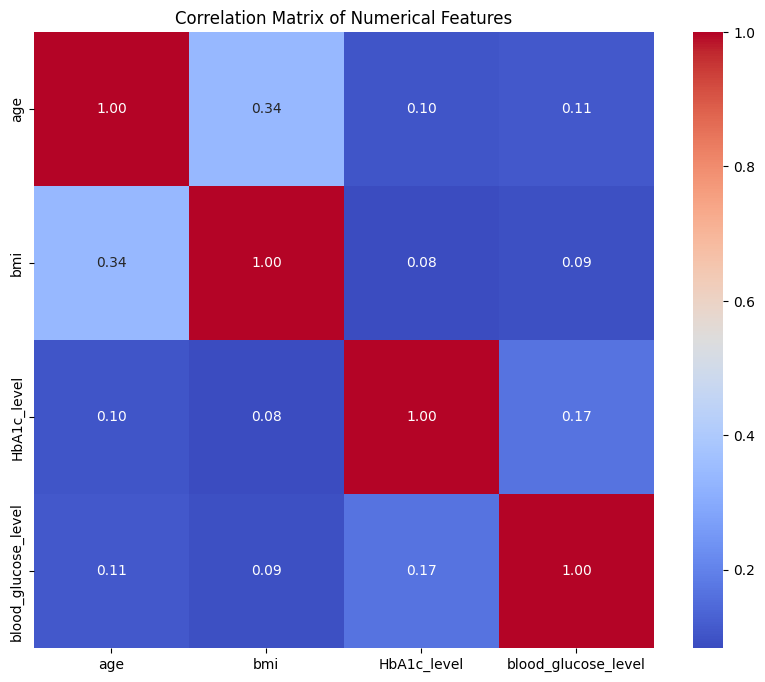

In [18]:
# 1. Correlation matrix/heatmap for all numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(diabetes_df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**This chart checks if two different numbers "move together."**

- Red colors mean a stronger connection. Blue colors mean a weak connection.

- The highest number here is 0.34 (between Age and BMI). This means there is a small link where older people tend to have a slightly higher BMI.

- Overall, the boxes are mostly blue, meaning these specific numbers (like Age and Blood Glucose) do not automatically go up and down together in a perfect straight line.

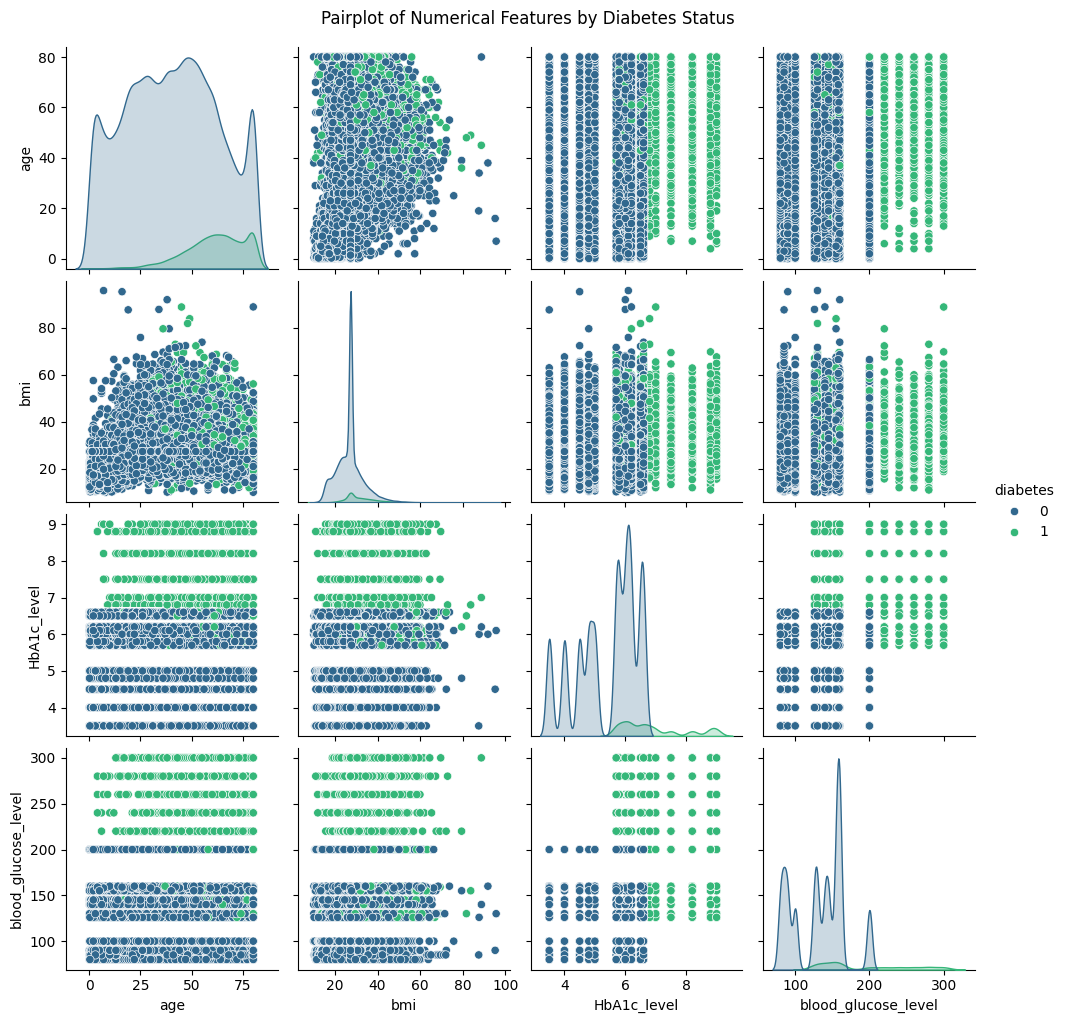

In [19]:
# 2. Pairplot analysis for numeric features colored by diabetes status
sns.pairplot(diabetes_df, vars=numerical_features, hue='diabetes', palette='viridis')
plt.suptitle('Pairplot of Numerical Features by Diabetes Status', y=1.02) # Adjust suptitle position
plt.show()

**This complex chart compares every category against every other category.**

- Blue dots: People without diabetes.

- Green dots: People with diabetes.

- Key takeaway: The green dots tend to cluster at the top and right edges of the small charts. This visually proves that people with diabetes usually have higher Age, higher BMI, and higher Blood Sugar levels compared to the blue dots.

/tmp/ipython-input-1496477851.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diabetes_rate_by_age_group = df_temp.groupby('age_group')['diabetes'].mean().reset_index()


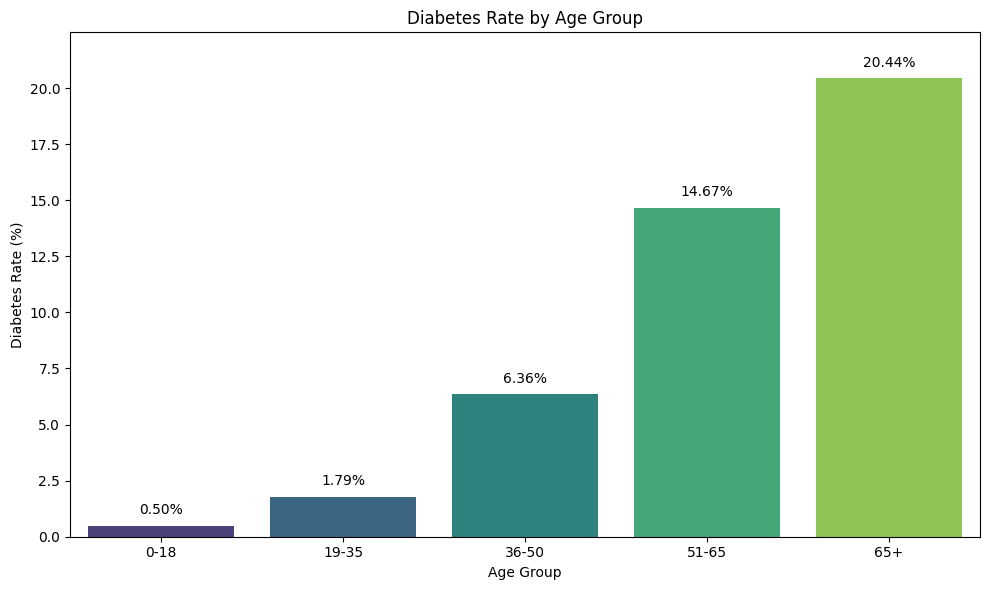

In [20]:
# 3. Age groups analysis: Create age brackets and analyze diabetes rates
age_bins = [0, 18, 35, 50, 65, diabetes_df['age'].max()]
age_labels = ['0-18', '19-35', '36-50', '51-65', '65+']
df_temp = diabetes_df.copy() # Create a copy to avoid SettingWithCopyWarning
df_temp['age_group'] = pd.cut(df_temp['age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

diabetes_rate_by_age_group = df_temp.groupby('age_group')['diabetes'].mean().reset_index()
diabetes_rate_by_age_group['diabetes_percentage'] = diabetes_rate_by_age_group['diabetes'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='diabetes_percentage', data=diabetes_rate_by_age_group, hue='age_group', legend=False, palette='viridis')
plt.title('Diabetes Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Rate (%)')
plt.ylim(0, diabetes_rate_by_age_group['diabetes_percentage'].max() * 1.1)

for index, row in diabetes_rate_by_age_group.iterrows():
    plt.text(index, row['diabetes_percentage'] + 0.5, f"{row['diabetes_percentage']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

**This simple bar chart shows the percentage of people with diabetes in different age groups.**

- Young People (0-35): Very few people have diabetes (less than 2%).

- Middle Age (36-50): The rate goes up to about 6.4%.

- Older Adults (51-65): The rate jumps to nearly 15%.

- Seniors (65+): This group has the highest rate, with over 20% having diabetes.

## **3.2. Risk Factor Combinations**

1. **Diabetes rates for patients with multiple comorbidities (hypertension + heart disease)**

2. **Smoking status + Gender interaction effects on diabetes rates**

3. **BMI categories (underweight, normal, overweight, obese) vs. diabetes by gender**

4. **Age + BMI interaction analysis**

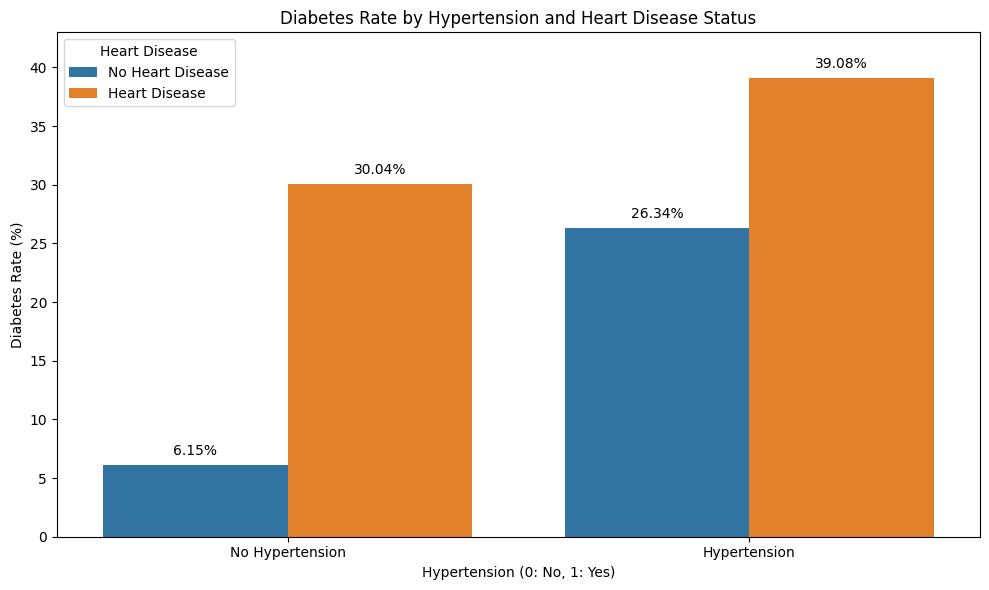

In [21]:
# 1. Diabetes rates for patients with multiple comorbidities (hypertension + heart disease)
comorbidity_diabetes_rate = diabetes_df.groupby(['hypertension', 'heart_disease'])['diabetes'].mean().reset_index()
comorbidity_diabetes_rate['diabetes_percentage'] = comorbidity_diabetes_rate['diabetes'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    x='hypertension',
    y='diabetes_percentage',
    hue='heart_disease',
    data=comorbidity_diabetes_rate
)
plt.title('Diabetes Rate by Hypertension and Heart Disease Status')
plt.xlabel('Hypertension (0: No, 1: Yes)')
plt.ylabel('Diabetes Rate (%)')
plt.xticks(ticks=[0, 1], labels=['No Hypertension', 'Hypertension'])
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['No Heart Disease', 'Heart Disease'], title='Heart Disease')
plt.ylim(0, comorbidity_diabetes_rate['diabetes_percentage'].max() * 1.1)

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f"{height:.2f}%",
                           (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='center', xytext=(0, 10),
                           textcoords='offset points')

plt.tight_layout()
plt.show()

**Hypertension and Heart Disease: People with these conditions are much more likely to have diabetes.**

- No Hypertension: The diabetes rate is low (about 6%).

- With Hypertension: The rate jumps up significantly (over 26%).

- Heart Disease Impact: In every category, people with heart disease (orange bars) have a higher diabetes rate than those without it (blue bars).

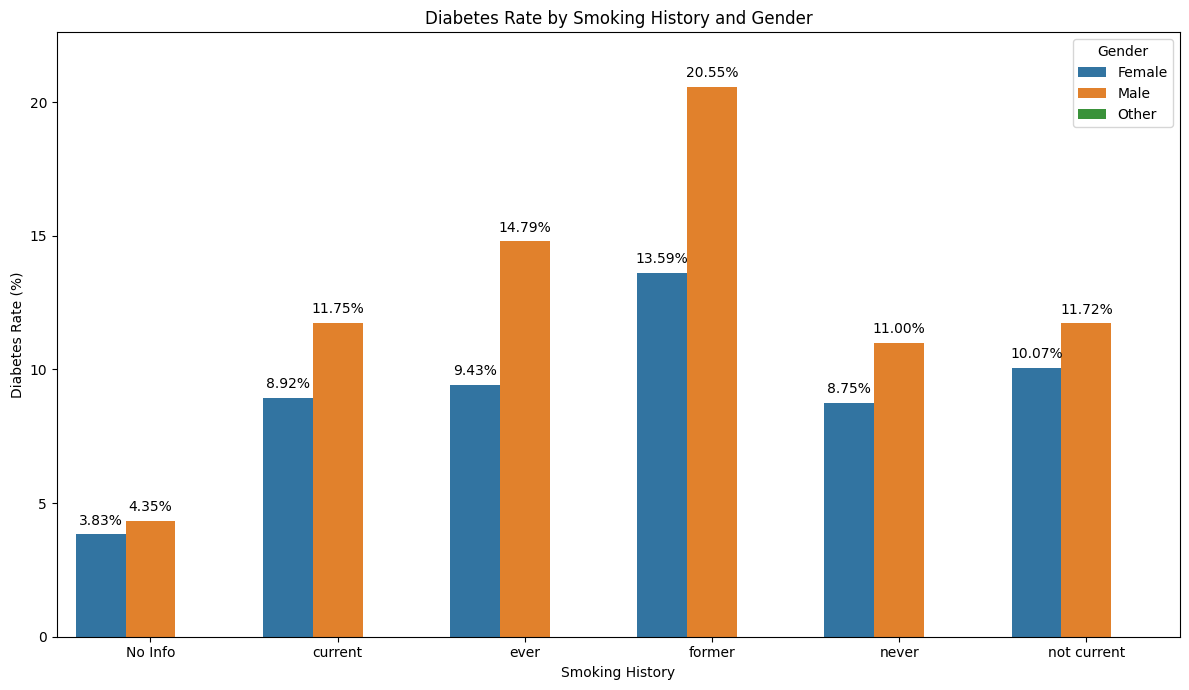

In [22]:
# 2. Smoking status + Gender interaction effects on diabetes rates
gender_smoking_diabetes_rate = diabetes_df.groupby(['smoking_history', 'gender'])['diabetes'].mean().reset_index()
gender_smoking_diabetes_rate['diabetes_percentage'] = gender_smoking_diabetes_rate['diabetes'] * 100

plt.figure(figsize=(12, 7))
sns.barplot(
    x='smoking_history',
    y='diabetes_percentage',
    hue='gender',
    data=gender_smoking_diabetes_rate
)
plt.title('Diabetes Rate by Smoking History and Gender')
plt.xlabel('Smoking History')
plt.ylabel('Diabetes Rate (%)')
plt.ylim(0, gender_smoking_diabetes_rate['diabetes_percentage'].max() * 1.1)
plt.legend(title='Gender')

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f"{height:.2f}%",
                           (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='center', xytext=(0, 10),
                           textcoords='offset points')

plt.tight_layout()
plt.show()

- Interestingly, "Former" smokers have the highest rates of diabetes (up to 20% for men).

- "Current" and "Never" smokers have lower rates.

- Across all smoking groups, men (orange) tend to have higher diabetes rates than women (blue).

/tmp/ipython-input-1926120961.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_gender_diabetes_rate = df_temp_bmi.groupby(['bmi_category', 'gender'])['diabetes'].mean().reset_index()


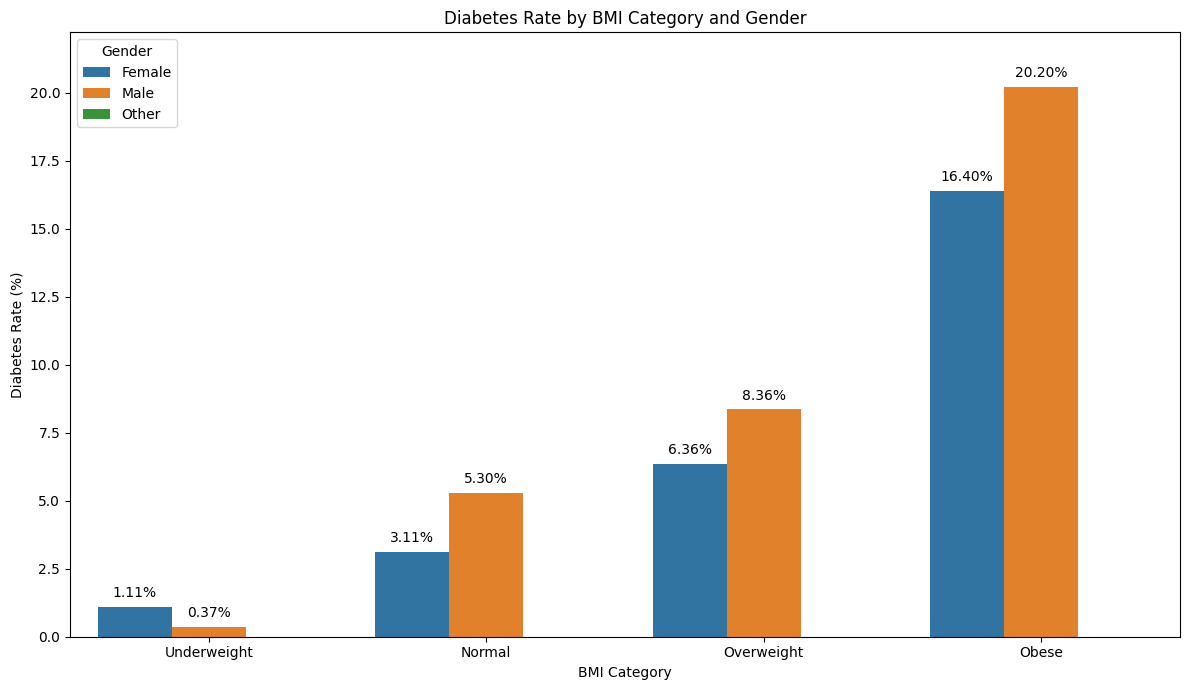

In [23]:
# 3. BMI categories (underweight, normal, overweight, obese) vs. diabetes by gender
bmi_bins = [0, 18.5, 24.9, 29.9, diabetes_df['bmi'].max()]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_temp_bmi = diabetes_df.copy()
df_temp_bmi['bmi_category'] = pd.cut(df_temp_bmi['bmi'], bins=bmi_bins, labels=bmi_labels, right=True, include_lowest=True)

bmi_gender_diabetes_rate = df_temp_bmi.groupby(['bmi_category', 'gender'])['diabetes'].mean().reset_index()
bmi_gender_diabetes_rate['diabetes_percentage'] = bmi_gender_diabetes_rate['diabetes'] * 100

plt.figure(figsize=(12, 7))
sns.barplot(
    x='bmi_category',
    y='diabetes_percentage',
    hue='gender',
    data=bmi_gender_diabetes_rate
)
plt.title('Diabetes Rate by BMI Category and Gender')
plt.xlabel('BMI Category')
plt.ylabel('Diabetes Rate (%)')
plt.ylim(0, bmi_gender_diabetes_rate['diabetes_percentage'].max() * 1.1)
plt.legend(title='Gender')

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f"{height:.2f}%",
                           (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='center', xytext=(0, 10),
                           textcoords='offset points')

plt.tight_layout()
plt.show()

- BMI Category: Weight has a very strong link to diabetes.

  - Underweight/Normal: Very low diabetes rates (around 1-5%).

  - Obese: The rate jumps to over 20% for men.

/tmp/ipython-input-182168149.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bmi_diabetes_rate = df_temp_age_bmi.groupby(['age_group', 'bmi_category'])['diabetes'].mean().unstack()


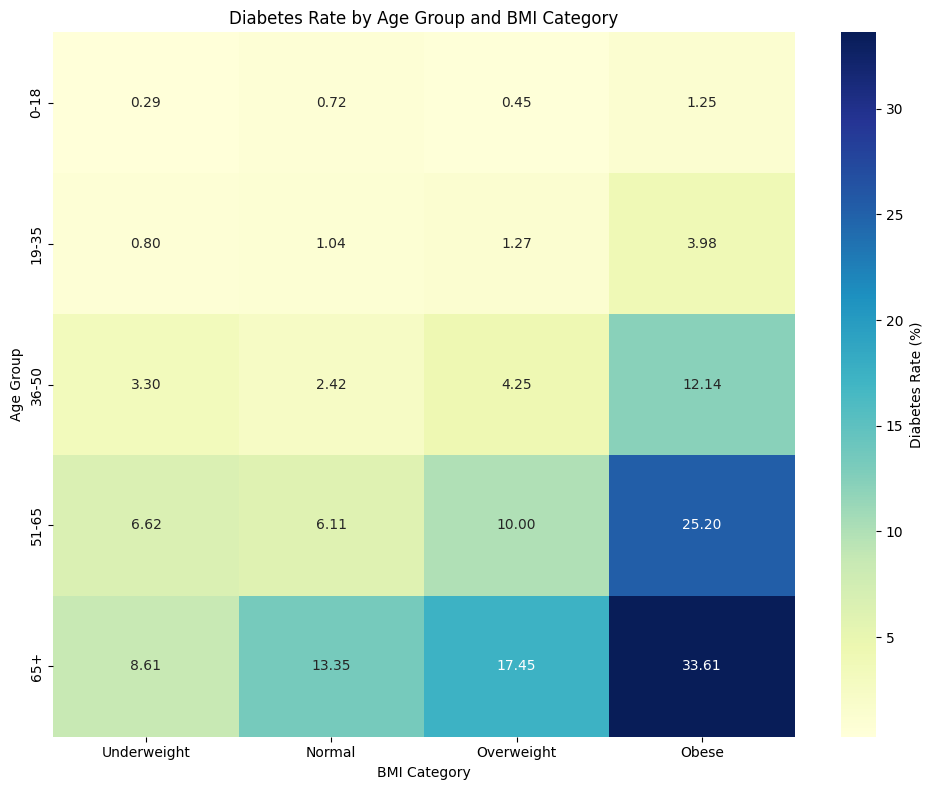

In [24]:
# 4. Age + BMI interaction analysis
# Re-define age_bins and age_labels for self-contained code
age_bins = [0, 18, 35, 50, 65, diabetes_df['age'].max()]
age_labels = ['0-18', '19-35', '36-50', '51-65', '65+']

df_temp_age_bmi = diabetes_df.copy()
df_temp_age_bmi['age_group'] = pd.cut(df_temp_age_bmi['age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)
df_temp_age_bmi['bmi_category'] = pd.cut(df_temp_age_bmi['bmi'], bins=bmi_bins, labels=bmi_labels, right=True, include_lowest=True)

age_bmi_diabetes_rate = df_temp_age_bmi.groupby(['age_group', 'bmi_category'])['diabetes'].mean().unstack()

plt.figure(figsize=(10, 8))
sns.heatmap(age_bmi_diabetes_rate * 100, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Diabetes Rate (%)'})
plt.title('Diabetes Rate by Age Group and BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

**This colored grid shows how Age and Weight work together.**

- Light Yellow (Top Left): Young people with low weight have the lowest risk (less than 1%).

- Dark Blue (Bottom Right): The risk gets higher as you get older and heavier. The highest diabetes rate (33.61%) is found in people who are both Senior (65+) and Obese.